In [1]:
import sys
import os

# 1. Add the build folder to Python's search path
sys.path.append(os.path.abspath("build"))

In [2]:
import specbridge as sb

In [3]:
n_clusters = 4

X shape: (480, 2)
labels shape: (480,)
centroids shape: (4, 2)


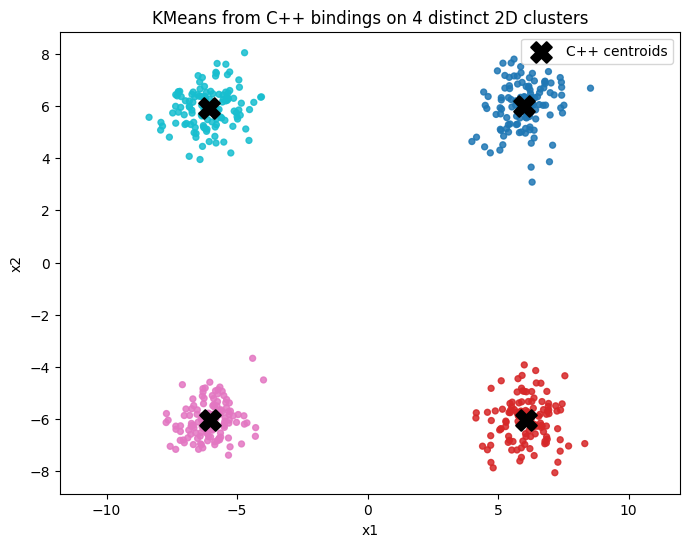

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducible synthetic data from 4 clearly separated 2D clusters
rng = np.random.default_rng(42)
points_per_cluster = 120
cluster_std = 0.8
centers = np.array([
    [-6.0, -6.0],
    [ 6.0, -6.0],
    [-6.0,  6.0],
    [ 6.0,  6.0],
])

X_parts = []
for c in centers:
    X_parts.append(rng.normal(loc=c, scale=cluster_std, size=(points_per_cluster, 2)))

X = np.vstack(X_parts).astype(np.float32)

kmeans = sb.KMeans(n_clusters=n_clusters, random_state=42)
result = kmeans.fit(X)

labels = np.array(result.labels)
centroids = np.array(result.centroids)

print("X shape:", X.shape)
print("labels shape:", labels.shape)
print("centroids shape:", centroids.shape)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="tab10", s=18, alpha=0.85)
plt.scatter(
    centroids[:, 0], centroids[:, 1],
    c="black", marker="X", s=220, linewidths=1.5, label="C++ centroids"
)
plt.title("KMeans from C++ bindings on 4 distinct 2D clusters")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.axis("equal")
plt.show()

SB labels shape: (480,)
#clusters recovered: 1
ngap: 0.0
eigvals (first 10): [-1.025121e-07 -1.025121e-07 -1.025121e-07 -1.025121e-07 -1.025121e-07
 -1.025121e-07 -1.025121e-07 -1.025121e-07 -1.025121e-07 -1.025121e-07]


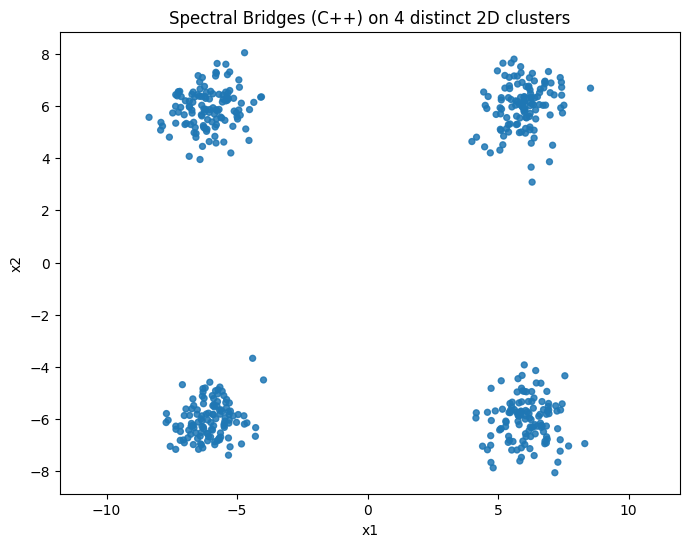

In [5]:
# Spectral Bridges test on the same 2D synthetic dataset X
k = n_clusters
m = 24          # number of Voronoi regions
p = 0.5
M = 1.0
n_iter = 20
seed = 42

sb_result = sb.spectral_bridges(
    X,
    k=k,
    m=m,
    p=p,
    M=M,
    n_iter=n_iter,
    random_state=seed,
 )

sb_labels = np.array(sb_result.labels)
sb_eigvals = np.array(sb_result.eigvals)

print("SB labels shape:", sb_labels.shape)
print("#clusters recovered:", len(np.unique(sb_labels)))
print("ngap:", sb_result.ngap)
print("eigvals (first 10):", sb_eigvals[:10])

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=sb_labels, cmap="tab10", s=18, alpha=0.85)
plt.title("Spectral Bridges (C++) on 4 distinct 2D clusters")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.show()